Data deduplication

In [1]:
# ============================================================
# 1. Mount Drive and clone project repo
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path
import os
import sys
import zipfile
import json
import random
from collections import Counter, defaultdict

import pandas as pd
import torch
from tqdm.auto import tqdm

REPO_URL = "https://github.com/angelo4o4/sixray-kd.git"
REPO_DIR = Path("/content/sixray-kd")

if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}

if str(REPO_DIR) not in sys.path:
    sys.path.append(str(REPO_DIR))

print("Repo ready:", REPO_DIR.exists())

Mounted at /content/drive
Cloning into '/content/sixray-kd'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 32 (delta 8), reused 28 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 1.64 MiB | 16.59 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Repo ready: True


In [18]:
SEED = 42
rand = random.Random(SEED)
rand.random()


SUBSET_ZIP = "/content/drive/MyDrive/DatasetAPAI/subset.zip"
SIXRAYD_ZIP = "/content/drive/MyDrive/DatasetAPAI_Anna/SIXray-D.zip"

#unzip if not present
if not Path(SUBSET_ZIP).exists():
    !unzip {SIXRAYD_ZIP} -d /content/data
    !unzip {SUBSET_ZIP} -d /content/data


In [74]:
#parse SIXray-D XMLs
#match XMLs to images in subset
#create train.json / val.json / test.json
#create merge_report.csv

from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd

SIXRAYD_ROOT = Path("/content/data/SIXray-D")

CLASS_TO_ID = {
    "gun": 0,
    "knife": 1,
    "wrench": 2,
    "pliers": 3,
    "plier": 3,
    "scissors": 4,
    "scissor" :4,
}

ID_TO_CLASS = {
    0: "gun",
    1: "knife",
    2: "wrench",
    3: "pliers",
    4: "scissors",
}

def parse_one_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename_tag = root.find("filename")
    filename = filename_tag.text if filename_tag is not None else xml_path.stem + ".jpg"

    xml_source_split = root.find("folder").text.lower().strip()

    if "train" in xml_source_split:
      xml_source_split = "train"
    else:
      xml_source_split = "test"
    size = root.find("size")
    width = int(size.find("width").text) if size is not None else None
    height = int(size.find("height").text) if size is not None else None

    objects = []

    for obj in root.findall("object"):
        raw_class_name = obj.find("name").text.lower().strip()
        if raw_class_name not in CLASS_TO_ID:
            print("Unknown class:", raw_class_name, "in", xml_path)
            continue

        class_id = CLASS_TO_ID[raw_class_name]
        class_name = ID_TO_CLASS[class_id]

        box = obj.find("bndbox")

        xmin = float(box.find("xmin").text)
        ymin = float(box.find("ymin").text)
        xmax = float(box.find("xmax").text)
        ymax = float(box.find("ymax").text)

        objects.append({
            "class_name": class_name,
            "class_id": class_id,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "width_box": xmax - xmin,
            "height_box": ymax - ymin,
        })

    return {
        "xml_path": str(xml_path),
        "xml_source_split": xml_source_split,
        "image_stem": Path(filename).stem,
        "filename": filename,
        "width": width,
        "height": height,
        "objects": objects,
        "num_boxes": len(objects),
    }

In [75]:
xml_files = list(SIXRAYD_ROOT.rglob("*.xml"))

print("XML files found:", len(xml_files))

records = []

for xml_path in xml_files:
    record = parse_one_xml(xml_path)
    records.append(record)

xml_df = pd.DataFrame(records)

xml_df.tail()

def merge_objects(group):
    # take first row as base
    row = group.iloc[0].copy()

    all_objects = []
    for objs in group["objects"]:
        if isinstance(objs, list):
            all_objects.extend(objs)

    # optional: remove exact duplicate boxes/classes
    unique_objects = []
    seen = set()

    for obj in all_objects:
        key = (
            obj["class_id"],
            obj["xmin"],
            obj["ymin"],
            obj["xmax"],
            obj["ymax"],
        )

        if key not in seen:
            seen.add(key)
            unique_objects.append(obj)

    row["objects"] = unique_objects
    row["num_boxes"] = len(unique_objects)

    return row


xml_df_unique = (
    xml_df
    .groupby("image_stem", as_index=False)
    .apply(merge_objects)
    .reset_index(drop=True)
)


print("Original XML rows:", len(xml_df))
print("Unique XML image stems:", len(xml_df_unique))
print("Total boxes before:", xml_df["num_boxes"].sum())
print("Total boxes after:", xml_df_unique["num_boxes"].sum()) # if = before, no boxes were lost
print("Images in train:", (xml_df_unique["xml_source_split"] == "train").sum())
print("Images in test:", (xml_df_unique["xml_source_split"] == "test").sum())

xml_df_unique.head()

XML files found: 10925
Original XML rows: 10925
Unique XML image stems: 10905
Total boxes before: 21592
Total boxes after: 21592
Images in train: 10069
Images in test: 836


/tmp/ipykernel_2879/140481126.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(merge_objects)


,xml_path,xml_source_split,image_stem,filename,width,height,objects,num_boxes
0,/content/data/SIXray-D/train/Cleaned Scissors ...,train,N0000055,N0000055.jpg,1380,1266,"[{'class_name': 'scissors', 'class_id': 4, 'xm...",2
1,/content/data/SIXray-D/train/Cleaned Scissors ...,train,N0000056,N0000056.jpg,1380,1362,"[{'class_name': 'scissors', 'class_id': 4, 'xm...",2
2,/content/data/SIXray-D/train/Cleaned Scissors ...,train,N0000057,N0000057.jpg,1380,1191,"[{'class_name': 'scissors', 'class_id': 4, 'xm...",2
3,/content/data/SIXray-D/train/Cleaned Scissors ...,train,N0000164,N0000164.jpg,992,1317,"[{'class_name': 'scissors', 'class_id': 4, 'xm...",1
4,/content/data/SIXray-D/train/Cleaned Scissors ...,train,N0000165,N0000165.jpg,992,1499,"[{'class_name': 'scissors', 'class_id': 4, 'xm...",1


In [76]:
# match to image paths

from pathlib import Path
import pandas as pd

IMAGE_ROOT = Path("/content/data/subset")

image_paths = list(IMAGE_ROOT.rglob("*.jpg"))

image_rows = []

for path in image_paths:
    rel_path = path.relative_to(IMAGE_ROOT).as_posix()
    stem = path.stem

    if rel_path.startswith("train/images/"):
        physical_split = "train"
    elif rel_path.startswith("test/images/"):
        physical_split = "test"
    else:
        physical_split = "unknown"

    image_rows.append({
        "image_stem": stem,
        "file_name": rel_path,
        "image_path": str(path),
        "physical_split": physical_split,
    })

images_df = pd.DataFrame(image_rows)
#drop duplicates
images_df = images_df.drop_duplicates("image_stem")

print("Images found:", len(images_df))
images_df.tail()

Images found: 88270


,image_stem,file_name,image_path,physical_split
88265,P04779,train/images/P04779.jpg,/content/data/subset/train/images/P04779.jpg,train
88266,P01299,train/images/P01299.jpg,/content/data/subset/train/images/P01299.jpg,train
88267,N0016354,train/images/N0016354.jpg,/content/data/subset/train/images/N0016354.jpg,train
88268,N0343290,train/images/N0343290.jpg,/content/data/subset/train/images/N0343290.jpg,train
88269,P00367,train/images/P00367.jpg,/content/data/subset/train/images/P00367.jpg,train


In [77]:
all_df = images_df.merge(
    xml_df_unique[["image_stem", "objects", "num_boxes", "width", "height", "xml_source_split"]],
    on="image_stem",
    how="left"
)

all_df["num_boxes"] = all_df["num_boxes"].fillna(0).astype(int)
all_df["objects"] = all_df["objects"].apply(lambda x: x if isinstance(x, list) else [])
all_df["is_positive"] = all_df["num_boxes"] > 0

print("Images:", len(images_df))
print("All records:", len(all_df))
print("Positive:", all_df["is_positive"].sum())
print("Negative:", (~all_df["is_positive"]).sum())

all_df.tail()

Images: 88270
All records: 88270
Positive: 8489
Negative: 79781


,image_stem,file_name,image_path,physical_split,objects,num_boxes,width,height,xml_source_split,is_positive
88265,P04779,train/images/P04779.jpg,/content/data/subset/train/images/P04779.jpg,train,"[{'class_name': 'scissors', 'class_id': 4, 'xm...",1,669.0,626.0,train,True
88266,P01299,train/images/P01299.jpg,/content/data/subset/train/images/P01299.jpg,train,"[{'class_name': 'pliers', 'class_id': 3, 'xmin...",3,928.0,777.0,test,True
88267,N0016354,train/images/N0016354.jpg,/content/data/subset/train/images/N0016354.jpg,train,[],0,NaN,NaN,NaN,False
88268,N0343290,train/images/N0343290.jpg,/content/data/subset/train/images/N0343290.jpg,train,[],0,NaN,NaN,NaN,False
88269,P00367,train/images/P00367.jpg,/content/data/subset/train/images/P00367.jpg,train,"[{'class_name': 'gun', 'class_id': 0, 'xmin': ...",3,652.0,640.0,train,True


Although SIXray-D XML annotations include their own train/test source folders, these folders are not aligned with the physical train/test folders of the provided subset. Therefore, the final split is based on the physical image location, while the XML source split is kept only as metadata. Because the annotation came from SIXray-D’s train folder, but the image file in our subset is stored in the test folder. These are two different split systems, and they do not match.

In [79]:
def get_class_names(objects):
    if not isinstance(objects, list) or len(objects) == 0:
        return ""
    names = sorted(set(obj["class_name"] for obj in objects))
    return ",".join(names)

def get_class_ids(objects):
    if not isinstance(objects, list) or len(objects) == 0:
        return ""
    ids = sorted(set(obj["class_id"] for obj in objects))
    return ",".join(map(str, ids))

def get_objects_summary(objects):
    if not isinstance(objects, list) or len(objects) == 0:
        return "negative"

    parts = []
    for obj in objects:
        parts.append(
            f'{obj["class_name"]}: '
            f'[{int(obj["xmin"])}, {int(obj["ymin"])}, '
            f'{int(obj["xmax"])}, {int(obj["ymax"])}]'
        )

    return " | ".join(parts)

all_df["class_names"] = all_df["objects"].apply(get_class_names)
all_df["class_ids"] = all_df["objects"].apply(get_class_ids)
all_df["objects_summary"] = all_df["objects"].apply(get_objects_summary)

all_df[[
    "file_name",
    "physical_split",
    "is_positive",
    "num_boxes",
    "class_names",
    "objects_summary"
]].head(20)

,file_name,physical_split,is_positive,num_boxes,class_names,objects_summary
0,test/images/N0131198.jpg,test,False,0,,negative
1,test/images/N0132206.jpg,test,False,0,,negative
2,test/images/N0619516.jpg,test,False,0,,negative
3,test/images/N0175779.jpg,test,False,0,,negative
4,test/images/N0879319.jpg,test,False,0,,negative
5,test/images/N0800333.jpg,test,False,0,,negative
6,test/images/N0936039.jpg,test,False,0,,negative
7,test/images/N0590836.jpg,test,False,0,,negative
8,test/images/P03833.jpg,test,True,3,pliers,"pliers: [165, 38, 222, 164] | pliers: [150, 88..."
9,test/images/N0364883.jpg,test,False,0,,negative


In [80]:
all_class_names = []

for objects in all_df["objects"]:
    for obj in objects:
        all_class_names.append(obj["class_name"])

pd.Series(all_class_names).value_counts()

,count
pliers,6363
gun,4868
wrench,3381
knife,2873
scissors,1417


In [81]:
all_class_ids = []

for objects in all_df["objects"]:
    for obj in objects:
        all_class_ids.append(obj["class_id"])

pd.Series(all_class_ids).value_counts().sort_index()

,count
0,4868
1,2873
2,3381
3,6363
4,1417


In [82]:
# lets use phash to get rid of duplicates
!pip install -q ImageHash

from PIL import Image
import imagehash
from tqdm.auto import tqdm

def compute_phash(path):
    with Image.open(path) as img:
        img = img.convert("RGB")
        return imagehash.phash(img, hash_size=8)

all_df["phash_obj"] = [
    compute_phash(path)
    for path in tqdm(all_df["image_path"], desc="Computing pHash")
]

all_df["phash"] = all_df["phash_obj"].astype(str)

print("Total images:", len(all_df))
print("Unique pHashes:", all_df["phash"].nunique())
print("Duplicated exact pHash rows:", all_df.duplicated("phash", keep=False).sum())



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.3 MB/s eta 0:00:00


Computing pHash:   0%|          | 0/88270 [00:00<?, ?it/s]

Total images: 88270
Unique pHashes: 86048
Duplicated exact pHash rows: 4235


In [84]:
from tqdm.auto import tqdm
from itertools import combinations

PHASH_THRESHOLD = 2

# Convert pHash string to integer
all_df["phash_int"] = all_df["phash"].apply(lambda x: int(str(x), 16))

n = len(all_df)

# Disjoint set union
parent = list(range(n))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra = find(a)
    rb = find(b)
    if ra != rb:
        parent[rb] = ra

# Precompute bit masks for Hamming distance 0, 1, 2
masks = [0]

# distance 1 masks
for i in range(64):
    masks.append(1 << i)

# distance 2 masks
for i, j in combinations(range(64), 2):
    masks.append((1 << i) | (1 << j))

print("Number of masks:", len(masks))

Number of masks: 2081


In [85]:
seen = {}

phash_ints = all_df["phash_int"].tolist()

for idx, h in tqdm(enumerate(phash_ints), total=len(phash_ints), desc="Grouping near pHashes"):
    for mask in masks:
        neighbor = h ^ mask

        if neighbor in seen:
            for other_idx in seen[neighbor]:
                union(idx, other_idx)

    # add current hash after checking previous ones
    if h not in seen:
        seen[h] = []
    seen[h].append(idx)

all_df["dedup_group"] = [find(i) for i in range(n)]

print("Total images:", len(all_df))
print("Dedup groups:", all_df["dedup_group"].nunique())
print("Images in duplicated groups:", all_df.duplicated("dedup_group", keep=False).sum())

Grouping near pHashes:   0%|          | 0/88270 [00:00<?, ?it/s]

Total images: 88270
Dedup groups: 84484
Images in duplicated groups: 6851


In [95]:
# Final automatic deduplication: identical pHash only
all_df["dedup_group"] = all_df["phash"]

print("Total images:", len(all_df))
print("Unique pHash groups:", all_df["dedup_group"].nunique())
print("Images in duplicated pHash groups:", all_df.duplicated("dedup_group", keep=False).sum())

Total images: 88270
Unique pHash groups: 86048
Images in duplicated pHash groups: 4235


In [96]:
cross_groups = []

for group_id, group in all_df.groupby("dedup_group"):
    if len(group) <= 1:
        continue

    if group["physical_split"].nunique() > 1:
        cross_groups.append({
            "dedup_group": group_id,
            "group_size": len(group),
            "splits": ",".join(sorted(group["physical_split"].unique())),
            "positive_count": int(group["is_positive"].sum()),
            "files": " | ".join(group["file_name"].head(10).tolist())
        })

cross_groups_df = pd.DataFrame(cross_groups)

print("Near-duplicate groups crossing physical train/test:", len(cross_groups_df))
cross_groups_df.head()

Near-duplicate groups crossing physical train/test: 461


,dedup_group,group_size,splits,positive_count,files
0,8a72fca58555d64a,2,"test,train",2,test/images/P01990.jpg | train/images/P01991.jpg
1,8b0f94f072fce223,2,"test,train",1,test/images/N0155843.jpg | train/images/N01558...
2,8ea5d2902d5e3d4b,2,"test,train",0,test/images/N0464107.jpg | train/images/N04641...
3,8ee2e091d7947a6a,2,"test,train",2,test/images/P02847.jpg | train/images/P00072.jpg
4,8fbfe080c7056a3e,2,"test,train",2,test/images/P00073.jpg | train/images/P02848.jpg


In [97]:
def count_unique_classes(objects):
    if not isinstance(objects, list):
        return 0
    return len(set(obj["class_id"] for obj in objects))

all_df["num_unique_classes"] = all_df["objects"].apply(count_unique_classes)

def split_priority(split):
    # keep test over train, because test is protected
    if split == "test":
        return 0
    return 1

kept_indices = []
decision_rows = []

for group_id, group in all_df.groupby("dedup_group"):
    group = group.copy()

    group["priority"] = group["physical_split"].apply(split_priority)

    group = group.sort_values(
        by=["priority", "num_boxes", "num_unique_classes", "file_name"],
        ascending=[True, False, False, True]
    )

    keep_idx = group.index[0]
    kept_indices.append(keep_idx)

    kept_file = all_df.loc[keep_idx, "file_name"]
    kept_split = all_df.loc[keep_idx, "physical_split"]

    for idx, row in group.iterrows():
        decision_rows.append({
            "dedup_group": group_id,
            "group_size": len(group),
            "file_name": row["file_name"],
            "physical_split": row["physical_split"],
            "is_positive": row["is_positive"],
            "num_boxes": row["num_boxes"],
            "class_names": row.get("class_names", ""),
            "phash": row["phash"],
            "is_kept": idx == keep_idx,
            "kept_file_name": kept_file,
            "kept_physical_split": kept_split,
        })

decision_df = pd.DataFrame(decision_rows)

clean_df = all_df.loc[kept_indices].copy().reset_index(drop=True)

print("Before:", len(all_df))
print("After:", len(clean_df))
print("Removed:", len(all_df) - len(clean_df))

print("\nBefore positive/negative:")
print(all_df["is_positive"].value_counts())

print("\nAfter positive/negative:")
print(clean_df["is_positive"].value_counts())

print("\nAfter physical split:")
print(clean_df["physical_split"].value_counts())

Before: 88270
After: 86048
Removed: 2222

Before positive/negative:
is_positive
False    79781
True      8489
Name: count, dtype: int64

After positive/negative:
is_positive
False    79083
True      6965
Name: count, dtype: int64

After physical split:
physical_split
train    72802
test     13246
Name: count, dtype: int64


In [89]:
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

def show_image_with_boxes(row, title=None):
    img = Image.open(row["image_path"]).convert("RGB")

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    ax.axis("off")

    objects = row["objects"]

    if isinstance(objects, list):
        for obj in objects:
            xmin = obj["xmin"]
            ymin = obj["ymin"]
            xmax = obj["xmax"]
            ymax = obj["ymax"]

            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                fill=False,
                linewidth=2
            )
            ax.add_patch(rect)

            ax.text(
                xmin,
                ymin,
                obj["class_name"],
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.7)
            )

    if title is not None:
        ax.set_title(title, fontsize=10)

    plt.show()

In [98]:
# groups with more than 1 image
group_sizes = all_df["dedup_group"].value_counts()

interesting_groups = group_sizes[group_sizes > 1]

print("Duplicate / near-duplicate groups:", len(interesting_groups))
print(interesting_groups.head(10))

Duplicate / near-duplicate groups: 2013
dedup_group
ea7ad5cc8d8da0b0    7
bfc0c03fcb3636c0    6
bf3dc0d24bc03627    6
f8308387bd1f9178    5
be6481dbcb8dc416    5
bfc0d027851cc7b3    5
b099c76693659c35    5
eac3942c1bf2e40f    5
9fe0c0c5f81d6f60    4
eb97963cc4633984    4
Name: count, dtype: int64


In [99]:
big_group_id = group_sizes.index[0]

big_group = all_df[all_df["dedup_group"] == big_group_id]

big_group[[
    "file_name",
    "physical_split",
    "is_positive",
    "num_boxes",
    "class_names",
    "phash"
]].head(30)

,file_name,physical_split,is_positive,num_boxes,class_names,phash
3320,test/images/P06524.jpg,test,True,2,scissors,ea7ad5cc8d8da0b0
10689,test/images/P06528.jpg,test,True,2,scissors,ea7ad5cc8d8da0b0
23733,train/images/P06527.jpg,train,True,2,scissors,ea7ad5cc8d8da0b0
26297,train/images/N0564132.jpg,train,False,0,,ea7ad5cc8d8da0b0
41008,train/images/P06533.jpg,train,True,2,scissors,ea7ad5cc8d8da0b0
60473,train/images/P06534.jpg,train,True,2,scissors,ea7ad5cc8d8da0b0
76727,train/images/P06526.jpg,train,True,2,scissors,ea7ad5cc8d8da0b0


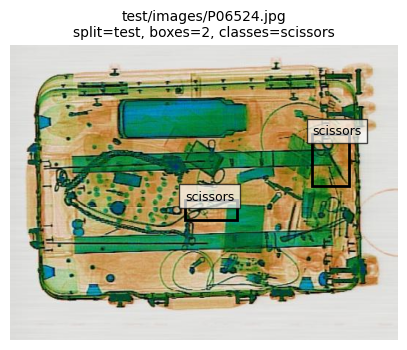

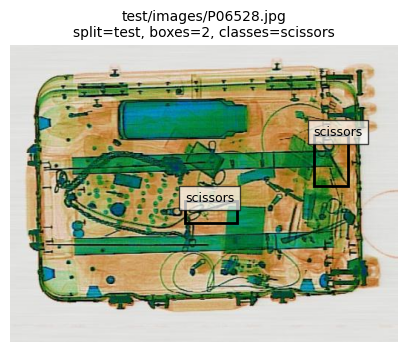

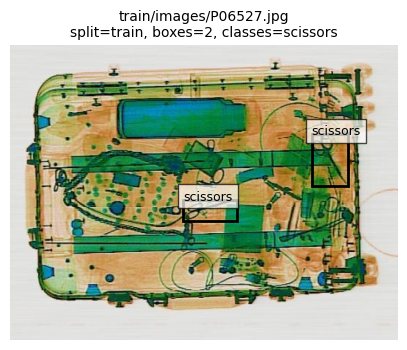

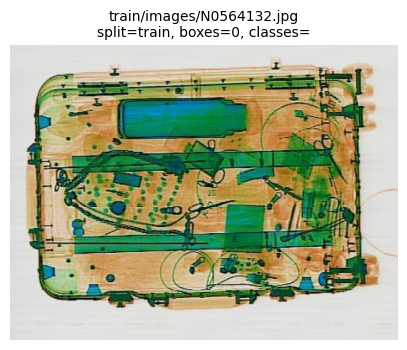

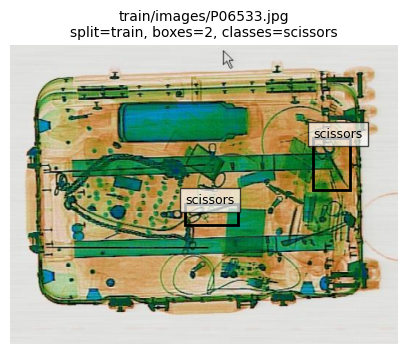

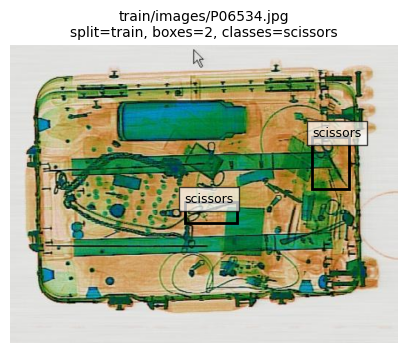

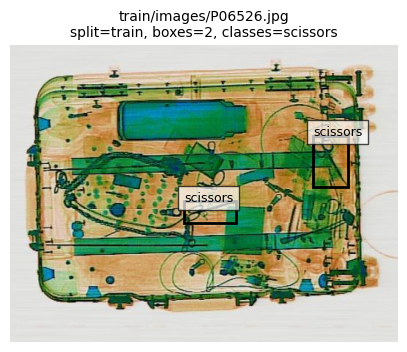

In [100]:
for _, row in big_group.head(10).iterrows():
    title = (
        f'{row["file_name"]}\n'
        f'split={row["physical_split"]}, '
        f'boxes={row["num_boxes"]}, '
        f'classes={row["class_names"]}'
    )
    show_image_with_boxes(row, title)

In [ ]:
from sklearn.model_selection import train_test_split

clean_df["final_split"] = None

# test stays test
test_idx = clean_df[clean_df["physical_split"] == "test"].index
clean_df.loc[test_idx, "final_split"] = "test"

# train physical pool becomes train/val
train_pool = clean_df[clean_df["physical_split"] == "train"]

train_idx, val_idx = train_test_split(
    train_pool.index,
    test_size=0.10,
    random_state=42,
    shuffle=True,
    stratify=train_pool["is_positive"]   # keeps pos/neg ratio similar
)

clean_df.loc[train_idx, "final_split"] = "train"
clean_df.loc[val_idx, "final_split"] = "val"

print(clean_df["final_split"].value_counts())
print()
print(pd.crosstab(clean_df["final_split"], clean_df["is_positive"]))